 # Utterance‑Level EDA of the L2‑ARCTIC Dataset



 This notebook performs **utterance‑level** exploratory data analysis (EDA) on the

 L2‑ARCTIC corpus using the processed Hugging Face dataset `KoelLabs/L2Arctic`.



 It relies on the helper module `utils.load_l2arctic`, which provides:



 - `load_scripted()`

 - `load_spontaneous()`


 In this notebook we:

 - Inspect corpus‑level statistics

 - Analyse speaker distributions

 - Examine utterance counts per speaker

 - Visualise duration and text‑length distributions.

 ## Setup



 Install and import required libraries. Run the cell below once in a fresh environment.

In [1]:
import sys
print(sys.executable)
print(sys.path[0])

/vol/bitbucket/tsv22/accent-robust-asr/.venv/bin/python
/usr/lib/python312.zip


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.load_l2arctic import load_scripted, load_spontaneous

sns.set(style="whitegrid")

 ## Load preprocessed data



 Use the helper functions to obtain ready‑to‑use DataFrames for scripted and

 spontaneous speech.

In [3]:
df = load_scripted()
# df = load_spontaneous()
df.head()

,audio,ipa,text,g2p,speaker_code,speaker_gender,speaker_native_language,duration_s,ipa_wstress,text_num_chars,text_num_words,ipa_num_chars
0,{'bytes': b'RIFFFg\x02\x00WAVEfmt \x10\x00\x00...,fɔɹðʌtwɛntiɪθtaɪmðætivnɪŋkðʌtumɛnʃʊkhænss,for the twentieth time that evening the two me...,fɔɹðʌtwɛntiʌθtaɪmðætivnɪŋðʌtumɛnʃʊkhændz,ABA,m,Arabic,4.920,fɔˈɹðʌˈtwɛˈntiɪθtaɪˈmðæˈtiˈvnɪŋkðʌˈtuˈmɛˈnʃʊˈk...,59,11,41
1,{'bytes': b'RIFF\x06+\x01\x00WAVEfmt \x10\x00\...,wɪlwiɛvʌfɔɹɡɛtɛt,will we ever forget it,wɪlwiɛvɝfɝɡɛtɪt,ABA,m,Arabic,2.390,wɪˈlwiˈɛˈvʌfɔɹɡɛˈtɛt,22,5,16
2,{'bytes': b'RIFF\xe6Q\x02\x00WAVEfmt \x10\x00\...,ɡɑdblɛsðʌmaɪhoʊpaɪlɡoʊɔnsiɪŋðɛmfɝɛvʌ,god bless em i hope i'll go on seeing them for...,ɡɑdblɛsɛmaɪhoʊpaɪlɡoʊɑnsiɪŋðɛmfɝɛvɝ,ABA,m,Arabic,4.749,ɡɑˈdblɛˈsðʌmaɪˈhoʊˈpaɪˈlɡoʊˈɔˈnsiˈɪŋðɛˈmfɝɛˈvʌ,50,11,36
3,{'bytes': b'RIFF\xc6n\x02\x00WAVEfmt \x10\x00\...,ændjuɔlwizwɔnttusiɛtɛnðʌsʊbɝlʌtɪvdɪɡɹi,and you always want to see it in the superlati...,ʌndjuɔlweɪzwɑnttusiɪtɪnðʌsʊpɝlʌtɪvdɪɡɹi,ABA,m,Arabic,4.980,æˈndjuˈɔˈlwizwɔˈnttuˈsiˈɛtɛnðʌsʊbɝˈlʌtɪvdɪɡɹiˈ,55,11,38
4,{'bytes': b'RIFFF\x8b\x01\x00WAVEfmt \x10\x00\...,ɡædjʊɹlɛtɹkeɪmdʒʌstɪntaɪm,gad your letter came just in time,ɡædjɔɹlɛtɝkeɪmdʒʌstɪntaɪm,ABA,m,Arabic,3.160,ɡæˈdjʊˈɹlɛˈtɹkeɪˈmdʒʌˈstɪntaɪˈm,33,7,25


 ## Corpus overview



 Compute high‑level statistics: number of utterances, total speech duration,

 and average utterance duration per split.

In [4]:
def corpus_stats(df):
    n_utts = len(df)
    total_minutes = df["duration_s"].sum() / 60
    mean_dur = df["duration_s"].mean()
    print(f"Split:")
    print(f"  Utterances: {n_utts:,}")
    print(f"  Total duration: {total_minutes:.2f} minutes")
    print(f"  Mean duration: {mean_dur:.2f} s")
    print("")


corpus_stats(df)

Split:
  Utterances: 3,599
  Total duration: 219.81 minutes
  Mean duration: 3.66 s



 ## Speaker distribution



 Examine how many speakers there are, and how they are distributed by gender and

 native language (L1).

Unique speakers: 24
Speaker metadata (scripted):
     speaker_code speaker_gender speaker_native_language
0             ABA              m                  Arabic
150           SKA              f                  Arabic
300          YBAA              m                  Arabic
449          ZHAA              f                  Arabic
599           BWC              m                 Chinese
749           LXC              f                 Chinese
899           NCC              f                 Chinese
1049         TXHC              m                 Chinese
1199          ASI              m                   Hindi
1349         RRBI              m                   Hindi
1499         SVBI              f                   Hindi
1649          TNI              f                   Hindi
1799          HJK              f                  Korean
1949          HKK              m                  Korean
2099         YDCK              f                  Korean
2249         YKWK              m       

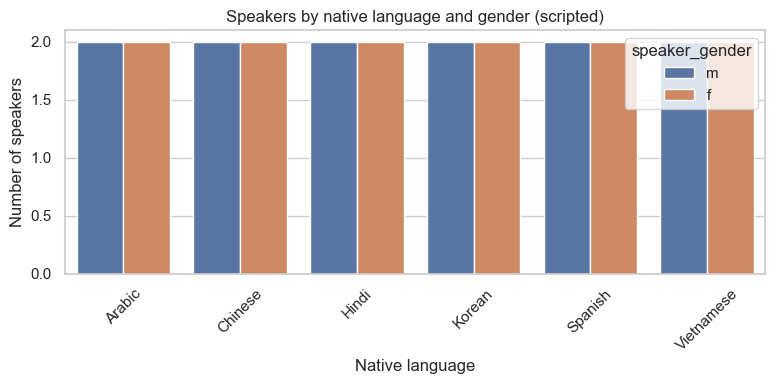

In [5]:
# Unique speakers per split
print("Unique speakers:", df["speaker_code"].nunique())

# Speaker counts by native language and gender (scripted)
speaker_meta_scripted = df[
    ["speaker_code", "speaker_gender", "speaker_native_language"]
].drop_duplicates()

print("Speaker metadata (scripted):")
print(
    speaker_meta_scripted.sort_values(
        ["speaker_native_language", "speaker_code"]
    )
)

# Plot speakers by native language
plt.figure(figsize=(8, 4))
sns.countplot(
    data=speaker_meta_scripted,
    x="speaker_native_language",
    hue="speaker_gender",
)
plt.title("Speakers by native language and gender (scripted)")
plt.xlabel("Native language")
plt.ylabel("Number of speakers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 ## Utterances per speaker



 Check how many utterances each speaker contributes to the corpus, focusing on

 the scripted split.

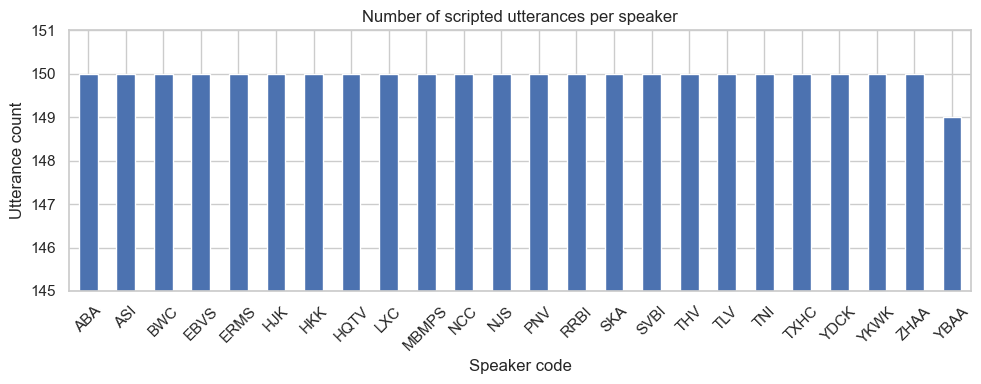

count     24.000000
mean     149.958333
std        0.204124
min      149.000000
25%      150.000000
50%      150.000000
75%      150.000000
max      150.000000
Name: text, dtype: float64

In [6]:
utt_counts = (
    df.groupby("speaker_code")["text"]
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 4))
ax = utt_counts.plot(kind="bar")
ax.set_ylim(145, 151)
plt.title("Number of scripted utterances per speaker")
plt.xlabel("Speaker code")
plt.ylabel("Utterance count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

utt_counts.describe()


 ## Duration distributions



 Visualise distributions of utterance durations for scripted and spontaneous

 speech, and compare across L1s.

/tmp/ipykernel_3857741/3778355363.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


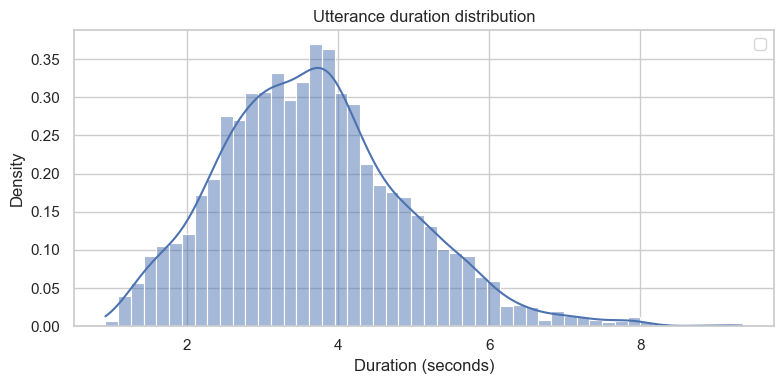

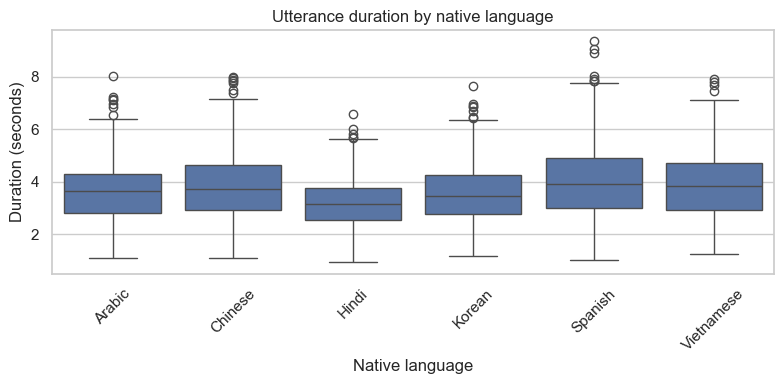

In [7]:
# Histogram of durations per split
plt.figure(figsize=(8, 4))
sns.histplot(
    df["duration_s"],
    bins=50,
    kde=True,
    color="C0",
    stat="density",
)
plt.legend()
plt.title("Utterance duration distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Boxplot of scripted durations by native language
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x="speaker_native_language",
    y="duration_s",
)
plt.title("Utterance duration by native language")
plt.xlabel("Native language")
plt.ylabel("Duration (seconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 ## Text and IPA transcription lengths



 Compute the number of characters and words in the orthographic transcription,

 and the length of the IPA transcription for the scripted split.

In [8]:
df[["text_num_chars", "text_num_words", "ipa_num_chars"]].describe()


,text_num_chars,text_num_words,ipa_num_chars
count,3599.000000,3599.000000,3599.000000
mean,49.149764,9.447069,34.704918
std,13.849528,2.413349,10.412539
min,17.000000,3.000000,10.000000
25%,39.000000,8.000000,27.000000
50%,51.000000,10.000000,35.000000
75%,59.000000,11.000000,42.000000
max,90.000000,16.000000,78.000000


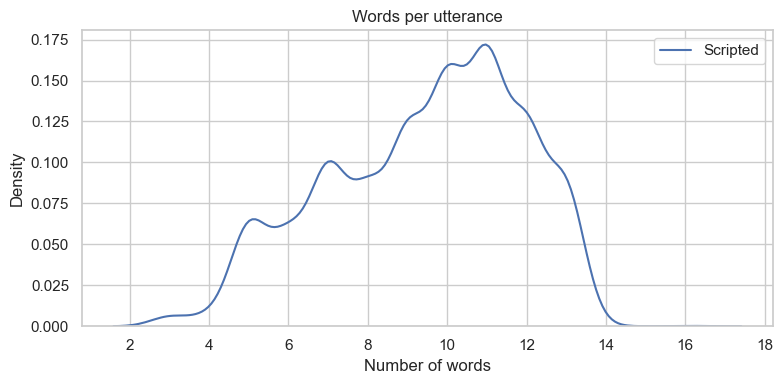

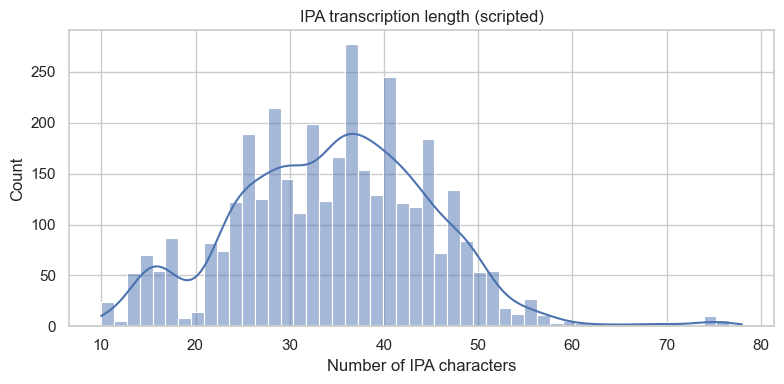

In [9]:
# Distributions of words per utterance (scripted vs spontaneous)
plt.figure(figsize=(8, 4))
sns.kdeplot(df["text_num_words"], label="Scripted")
plt.title("Words per utterance")
plt.xlabel("Number of words")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# IPA length distribution (scripted)
plt.figure(figsize=(8, 4))
sns.histplot(df["ipa_num_chars"], bins=50, kde=True)
plt.title("IPA transcription length (scripted)")
plt.xlabel("Number of IPA characters")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


 ## Duration vs. text length



 Check the relationship between utterance duration and the number of words in

 the transcription for the scripted split.

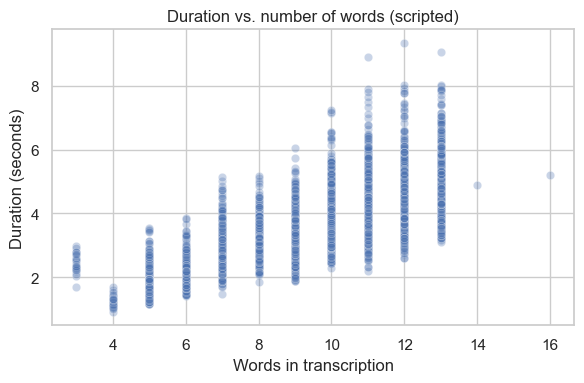

,text_num_words,duration_s
text_num_words,1.000000,0.734938
duration_s,0.734938,1.000000


In [10]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x="text_num_words",
    y="duration_s",
    data=df,
    alpha=0.3,
)
plt.title("Duration vs. number of words (scripted)")
plt.xlabel("Words in transcription")
plt.ylabel("Duration (seconds)")
plt.tight_layout()
plt.show()

df[["text_num_words", "duration_s"]].corr()